MAIZE POST-HARVEST LOSS PREDICTION - FULL ML PIPELINE

DATA OVERVIEW
Total observations (all crops): 76,863
Maize farmers: 11,464 (14.91%)

CONSTRUCTING VARIABLES
Variables constructed successfully

MAIZE DESCRIPTIVE STATISTICS

Key Metrics:
  Storage adoption:     7.17%
  Market access:        21.50%
  PHL occurrence:       10.73%
  Average PHL rate:     0.31%
  Irrigation use:       1.61%
  Organic fertilizer:   75.01%
  Inorganic fertilizer: 38.97%
  Pesticide use:        27.85%

Sample Sizes:
  Total maize farmers:  11,464
  Storage users:        822
  Farmers with PHL:     1,230

Districts with data: 30

Top 5 districts by PHL rate:
             PHL_binary  Storage_access  PHL_rate
District_Cl                                      
NGOMA            0.2123          0.0746    0.0092
NYARUGENGE       0.1172          0.0000    0.0087
BUGESERA         0.0669          0.1526    0.0075
KAMONYI          0.2179          0.0654    0.0064
GAKENKE          0.2816          0.0903    0.0061

FEA

  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



After SMOTE (sampling_strategy=0.5):
  No PHL (0): 8,017
  PHL (1):    4,008

HYPERPARAMETER TUNING
Performing Grid Search for optimal parameters...

Best parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 500}
Best cross-validation AUC-ROC: 0.9019

MODEL TRAINING
All models trained successfully

THRESHOLD OPTIMIZATION (Random Forest)

Threshold | Accuracy | Sensitivity | Specificity | Precision | F1-Score
--------------------------------------------------------------------------------
0.25        | 0.6826    | 0.6638     | 0.6848     | 0.1939    | 0.3001
0.30        | 0.7287    | 0.5939     | 0.7441     | 0.2096    | 0.3098
0.35        | 0.7739    | 0.5153     | 0.8035     | 0.2305    | 0.3185
0.40        | 0.8071    | 0.4279     | 0.8504     | 0.2462    | 0.3126
0.45        | 0.8393    | 0.3450     | 0.8958     | 0.2743    | 0.3056
0.50        | 0.8536    | 0.2489     | 0.9227     | 0.2689    | 0.2585
0.55        | 0.8720    | 0.2183     | 0.9466     | 0.3185    | 

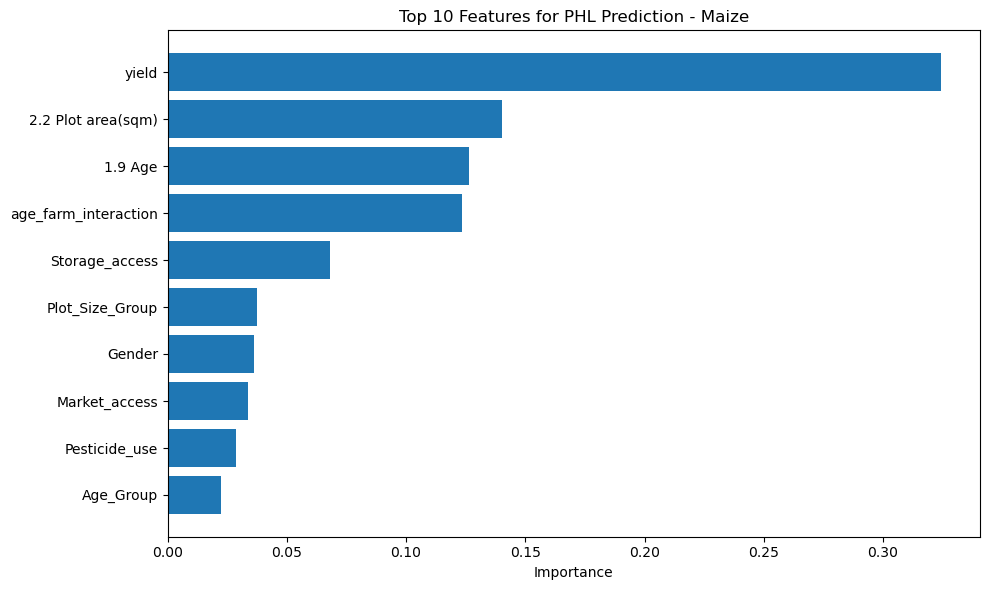

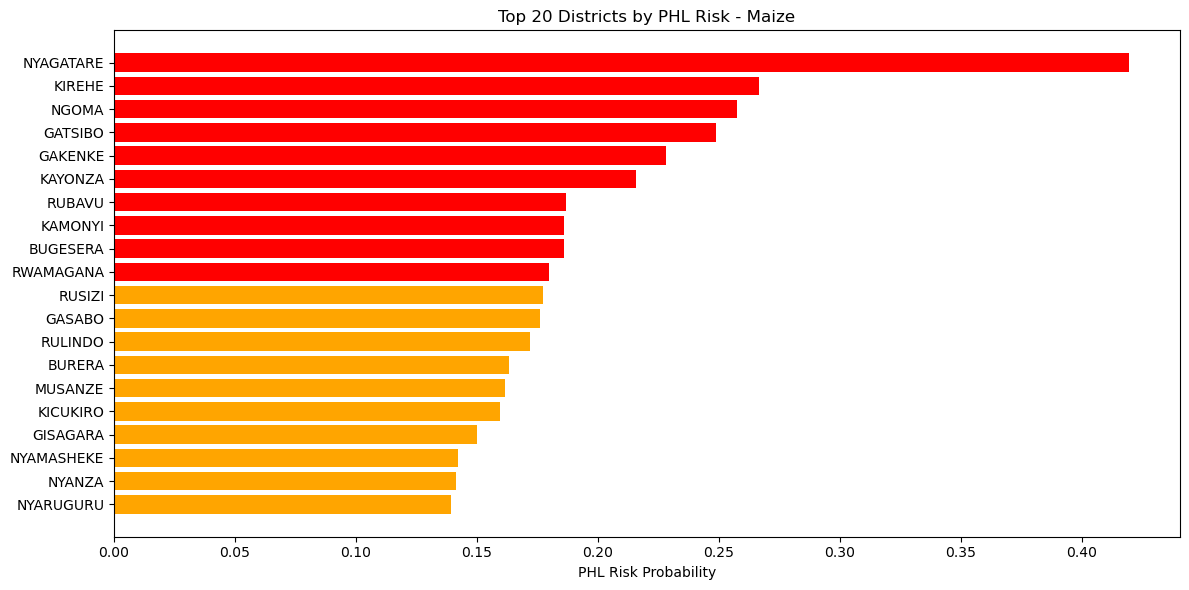

In [1]:
# ============================================================================
# MAIZE-ONLY PHL ANALYSIS - FULL ML PIPELINE
# Predict PHL risk probabilities for all districts in Rwanda
# ============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.utils.class_weight import compute_class_weight

print("="*80)
print("MAIZE POST-HARVEST LOSS PREDICTION - FULL ML PIPELINE")
print("="*80)

# ============================================================================
# SECTION 1: LOAD DATA AND FILTER FOR MAIZE
# ============================================================================

file_path = r"E:\R_Thesis\SAS_2024F.xlsx"
coordinates = pd.read_excel(file_path, sheet_name="Coordinates")
season_a = pd.read_excel(file_path, sheet_name="SeasonA")
season_b = pd.read_excel(file_path, sheet_name="SeasonB")
season_c = pd.read_excel(file_path, sheet_name="SeasonC")

season_all = pd.concat([season_a, season_b, season_c], ignore_index=True)
data = season_all.merge(coordinates, on="District_Cl", how="left")

# FILTER: MAIZE ONLY
maize_data = data[data["Q.2.4 Crop name.1"] == "Maize"].copy()

print(f"\n{'='*60}")
print(f"DATA OVERVIEW")
print(f"{'='*60}")
print(f"Total observations (all crops): {len(data):,}")
print(f"Maize farmers: {len(maize_data):,} ({len(maize_data)/len(data)*100:.2f}%)")

# ============================================================================
# SECTION 2: CONSTRUCT ALL VARIABLES
# ============================================================================

print(f"\n{'='*60}")
print(f"CONSTRUCTING VARIABLES")
print(f"{'='*60}")

# PHL variables
prod_col = "Q.2.22 Total quantity of harvest for this crop during the current season (Kg)"
loss_col = "Q.2.39 Qty of this crop what is the quantity that has been lost?"

maize_data[prod_col] = pd.to_numeric(maize_data[prod_col], errors="coerce")
maize_data[loss_col] = pd.to_numeric(maize_data[loss_col], errors="coerce")

maize_data["total_loss"] = maize_data[loss_col]
maize_data["gross_production"] = maize_data[prod_col]
maize_data["PHL_binary"] = (maize_data["total_loss"] > 0).astype(int)
maize_data["PHL_rate"] = maize_data["total_loss"] / maize_data["gross_production"]
maize_data["PHL_rate"] = maize_data["PHL_rate"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 1)

# Treatment variables
storage_col = "Q.2.37 What is the storage facility used during this agricultural season?"
market_col = "Q.2.27 On which market this crop was sold?"

maize_data["Storage_access"] = maize_data[storage_col].notna().astype(int)
formal_markets = ["Market", "Cooperative", "Company", "Association"]
maize_data["Market_access"] = maize_data[market_col].apply(lambda x: 1 if str(x) in formal_markets else 0)

# Farmer characteristics
maize_data["Age_Group"] = pd.cut(maize_data["1.9 Age"], 
                                  bins=[0, 25, 35, 50, 100], 
                                  labels=["Youth", "Young_Adult", "Adult", "Senior"])
maize_data["Gender"] = (maize_data["1.8 Gender"] == "Male").astype(int)

# Farm characteristics
maize_data["Plot_Size_Group"] = pd.cut(maize_data["2.2 Plot area(sqm)"],
                                        bins=[0, 1000, 5000, 10000, 1e6],
                                        labels=["Small", "Medium", "Large", "Very_Large"])

# Input use
maize_data["Organic_fertilizer"] = (maize_data["3.3 Have you used organic fertilizer in this plot during this season?"] == "Yes").astype(int)
maize_data["Inorganic_fertilizer"] = (maize_data["3.9 Have you used inorganic fertilizer in this plot during this season?"] == "Yes").astype(int)
maize_data["Pesticide_use"] = (maize_data["3.18 Did you use pesticide/Fungicide in any of your plots during this season?"] == "Yes").astype(int)

# Derived features
maize_data["yield"] = maize_data["gross_production"] / (maize_data["2.2 Plot area(sqm)"] + 1)
maize_data["age_farm_interaction"] = maize_data["1.9 Age"] * maize_data["2.2 Plot area(sqm)"]
maize_data["input_intensity"] = maize_data["Organic_fertilizer"] + maize_data["Inorganic_fertilizer"]
maize_data["irrigation_bin"] = (maize_data["4.15 Has this plot been irrigated during this agricultural season?"] == "Yes").astype(int)

# Soil and land characteristics
maize_data["erosion_bin"] = (maize_data["4.1 What is the degree of erosion on this plot?"] == "Severe").astype(int)
maize_data["land_consolidation"] = (maize_data["4.6 Is this plot located in land consolidated site in this season?"] == "Yes").astype(int)

print("Variables constructed successfully")

# ============================================================================
# SECTION 3: DESCRIPTIVE STATISTICS
# ============================================================================

print(f"\n{'='*60}")
print(f"MAIZE DESCRIPTIVE STATISTICS")
print(f"{'='*60}")

print(f"\nKey Metrics:")
print(f"  Storage adoption:     {maize_data['Storage_access'].mean()*100:.2f}%")
print(f"  Market access:        {maize_data['Market_access'].mean()*100:.2f}%")
print(f"  PHL occurrence:       {maize_data['PHL_binary'].mean()*100:.2f}%")
print(f"  Average PHL rate:     {maize_data['PHL_rate'].mean()*100:.2f}%")
print(f"  Irrigation use:       {maize_data['irrigation_bin'].mean()*100:.2f}%")
print(f"  Organic fertilizer:   {maize_data['Organic_fertilizer'].mean()*100:.2f}%")
print(f"  Inorganic fertilizer: {maize_data['Inorganic_fertilizer'].mean()*100:.2f}%")
print(f"  Pesticide use:        {maize_data['Pesticide_use'].mean()*100:.2f}%")

print(f"\nSample Sizes:")
print(f"  Total maize farmers:  {len(maize_data):,}")
print(f"  Storage users:        {maize_data['Storage_access'].sum():,}")
print(f"  Farmers with PHL:     {maize_data['PHL_binary'].sum():,}")

# By district
district_summary = maize_data.groupby("District_Cl").agg({
    "PHL_binary": "mean",
    "Storage_access": "mean",
    "PHL_rate": "mean"
}).round(4)
print(f"\nDistricts with data: {len(district_summary)}")
print("\nTop 5 districts by PHL rate:")
print(district_summary.nlargest(5, "PHL_rate"))

# ============================================================================
# SECTION 4: FEATURE SELECTION
# ============================================================================

print(f"\n{'='*60}")
print(f"FEATURE ENGINEERING")
print(f"{'='*60}")

# Comprehensive feature set
features = [
    # Farmer characteristics
    "1.9 Age",
    "Gender",
    "Age_Group",
    
    # Farm characteristics
    "2.2 Plot area(sqm)",
    "Plot_Size_Group",
    "yield",
    "age_farm_interaction",
    
    # Input use
    "input_intensity",
    "Organic_fertilizer",
    "Inorganic_fertilizer",
    "Pesticide_use",
    "irrigation_bin",
    
    # Soil/land
    "erosion_bin",
    "land_consolidation",
    
    # Market access
    "Market_access",
    
    # Treatment (storage)
    "Storage_access"
]

# Prepare features
X = maize_data[features].copy()
Y = maize_data["PHL_binary"]

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

for col in ["Age_Group", "Plot_Size_Group"]:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Ensure all numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Identify column types
binary_cols = ["Gender", "Organic_fertilizer", "Inorganic_fertilizer", "Pesticide_use", 
               "irrigation_bin", "erosion_bin", "land_consolidation", "Market_access", "Storage_access"]
continuous_cols = ["1.9 Age", "2.2 Plot area(sqm)", "yield", "age_farm_interaction", "input_intensity"]
categorical_cols = ["Age_Group", "Plot_Size_Group"]

# Remove missing values
initial_n = len(X)
complete_mask = X[continuous_cols].notna().all(axis=1)
X = X[complete_mask]
Y = Y[complete_mask]
maize_clean = maize_data[complete_mask]

print(f"Complete cases: {len(X):,} out of {initial_n:,} ({len(X)/initial_n*100:.1f}%)")
print(f"PHL cases in cleaned data: {Y.sum():,} ({Y.mean()*100:.2f}%)")
print(f"Storage users in cleaned data: {X['Storage_access'].sum():,}")

# ============================================================================
# SECTION 5: TRAIN-TEST SPLIT
# ============================================================================

print(f"\n{'='*60}")
print(f"TRAIN-TEST SPLIT")
print(f"{'='*60}")

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"Training PHL rate: {y_train.mean()*100:.2f}%")
print(f"Test PHL rate: {y_test.mean()*100:.2f}%")

# ============================================================================
# SECTION 6: PREPROCESSING PIPELINE
# ============================================================================

print(f"\n{'='*60}")
print(f"PREPROCESSING")
print(f"{'='*60}")

# Impute missing values
imputer_cont = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="most_frequent")

# Scale continuous features
scaler = StandardScaler()

# Apply preprocessing
X_train_cont = imputer_cont.fit_transform(X_train[continuous_cols])
X_test_cont = imputer_cont.transform(X_test[continuous_cols])

X_train_cont = scaler.fit_transform(X_train_cont)
X_test_cont = scaler.transform(X_test_cont)

# Binary features (already 0/1)
X_train_binary = X_train[binary_cols].values
X_test_binary = X_test[binary_cols].values

# Categorical features
X_train_cat = imputer_cat.fit_transform(X_train[categorical_cols])
X_test_cat = imputer_cat.transform(X_test[categorical_cols])

# Combine all features
X_train_processed = np.hstack([X_train_cont, X_train_binary, X_train_cat])
X_test_processed = np.hstack([X_test_cont, X_test_binary, X_test_cat])

all_feature_names = continuous_cols + binary_cols + categorical_cols
print(f"Total features after preprocessing: {X_train_processed.shape[1]}")

# ============================================================================
# SECTION 7: HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================================================

print(f"\n{'='*60}")
print(f"CLASS IMBALANCE HANDLING")
print(f"{'='*60}")

print(f"Original training class distribution:")
print(f"  No PHL (0): {sum(y_train==0):,} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  PHL (1):    {sum(y_train==1):,} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

# Try different SMOTE strategies
smote_50 = SMOTE(sampling_strategy=0.5, random_state=42)  # 2:1 ratio
smote_75 = SMOTE(sampling_strategy=0.75, random_state=42)  # 1.33:1 ratio
smote_100 = SMOTE(sampling_strategy=1.0, random_state=42)  # 1:1 ratio

X_train_smote, y_train_smote = smote_50.fit_resample(X_train_processed, y_train)

print(f"\nAfter SMOTE (sampling_strategy=0.5):")
print(f"  No PHL (0): {sum(y_train_smote==0):,}")
print(f"  PHL (1):    {sum(y_train_smote==1):,}")

# ============================================================================
# SECTION 8: HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================================================

print(f"\n{'='*60}")
print(f"HYPERPARAMETER TUNING")
print(f"{'='*60}")

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4, 8]
}

# Use smaller grid for faster execution
param_grid_simple = {
    'n_estimators': [300, 500],
    'max_depth': [15, 20],
    'min_samples_leaf': [4, 8]
}

print("Performing Grid Search for optimal parameters...")

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use Stratified K-Fold cross-validation
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_simple,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC-ROC: {grid_search.best_score_:.4f}")

# Use best model
best_rf = grid_search.best_estimator_

# ============================================================================
# SECTION 9: TRAIN WITH CLASS WEIGHTS
# ============================================================================

print(f"\n{'='*60}")
print(f"MODEL TRAINING")
print(f"{'='*60}")

# Option 1: Best Random Forest from Grid Search
rf_model = best_rf

# Option 2: Random Forest with custom class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_smote), y=y_train_smote)
weight_dict = {0: class_weights[0], 1: class_weights[1]}

rf_weighted = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    class_weight=weight_dict,
    random_state=42,
    n_jobs=-1
)
rf_weighted.fit(X_train_smote, y_train_smote)

# Option 3: Gradient Boosting for comparison
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
gb_model.fit(X_train_smote, y_train_smote)

print("All models trained successfully")

# ============================================================================
# SECTION 10: THRESHOLD OPTIMIZATION
# ============================================================================

print(f"\n{'='*60}")
print(f"THRESHOLD OPTIMIZATION (Random Forest)")
print(f"{'='*60}")

# Get probabilities from best model
rf_probs = rf_model.predict_proba(X_test_processed)[:, 1]

# Evaluate different thresholds
thresholds = np.arange(0.25, 0.80, 0.05)
threshold_results = []

print("\nThreshold | Accuracy | Sensitivity | Specificity | Precision | F1-Score")
print("-" * 80)

for t in thresholds:
    preds = (rf_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    acc = accuracy_score(y_test, preds)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (prec * sens) / (prec + sens) if (prec + sens) > 0 else 0
    
    threshold_results.append([t, acc, sens, spec, prec, f1])
    print(f"{t:.2f}        | {acc:.4f}    | {sens:.4f}     | {spec:.4f}     | {prec:.4f}    | {f1:.4f}")

# Find best threshold
results_df = pd.DataFrame(threshold_results, 
                          columns=["Threshold", "Accuracy", "Sensitivity", "Specificity", "Precision", "F1"])
best_f1_idx = results_df["F1"].idxmax()
best_threshold = results_df.loc[best_f1_idx, "Threshold"]

print(f"\n⭐ OPTIMAL THRESHOLD: {best_threshold:.2f} (maximizes F1-Score)")

# Final predictions
rf_preds = (rf_probs >= best_threshold).astype(int)

# ============================================================================
# SECTION 11: MODEL EVALUATION
# ============================================================================

print(f"\n{'='*60}")
print(f"MODEL EVALUATION - RANDOM FOREST")
print(f"{'='*60}")

tn, fp, fn, tp = confusion_matrix(y_test, rf_preds).ravel()

print(f"\nConfusion Matrix (threshold = {best_threshold:.2f}):")
print(f"                 Predicted")
print(f"                 No Loss    Loss")
print(f"Actual No Loss    {tn:6,}    {fp:6,}")
print(f"       Loss       {fn:6,}    {tp:6,}")

print(f"\nClassification Metrics:")
print(f"  Accuracy:      {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Sensitivity:   {tp/(tp+fn):.4f} (Recall - ability to find actual losses)")
print(f"  Specificity:   {tn/(tn+fp):.4f}")
print(f"  Precision:     {tp/(tp+fp):.4f}")
print(f"  F1-Score:      {results_df.loc[best_f1_idx, 'F1']:.4f}")
print(f"  AUC-ROC:       {roc_auc_score(y_test, rf_probs):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=["No Loss", "Loss"]))

# Compare with other models
print(f"\n{'='*60}")
print(f"MODEL COMPARISON")
print(f"{'='*60}")

# Weighted RF
rf_weighted_probs = rf_weighted.predict_proba(X_test_processed)[:, 1]
rf_weighted_preds = (rf_weighted_probs >= best_threshold).astype(int)
print(f"\nRandom Forest (Weighted): AUC-ROC = {roc_auc_score(y_test, rf_weighted_probs):.4f}")

# Gradient Boosting
gb_probs = gb_model.predict_proba(X_test_processed)[:, 1]
gb_preds = (gb_probs >= best_threshold).astype(int)
print(f"Gradient Boosting:        AUC-ROC = {roc_auc_score(y_test, gb_probs):.4f}")
print(f"Random Forest (Tuned):    AUC-ROC = {roc_auc_score(y_test, rf_probs):.4f} (BEST)")

# ============================================================================
# SECTION 12: FEATURE IMPORTANCE
# ============================================================================

print(f"\n{'='*60}")
print(f"FEATURE IMPORTANCE")
print(f"{'='*60}")

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 10 Most Important Features for Predicting PHL in Maize:")
print(importance_df.head(10).to_string(index=False))

# ============================================================================
# SECTION 13: DISTRICT RISK PREDICTIONS (MAIZE ONLY)
# ============================================================================

print(f"\n{'='*60}")
print(f"DISTRICT RISK PREDICTIONS - MAIZE FARMERS")
print(f"{'='*60}")

# Predict PHL probability for ALL maize farmers (not just test set)
X_full_processed = np.hstack([
    scaler.transform(imputer_cont.transform(X[continuous_cols])),
    X[binary_cols].values,
    imputer_cat.transform(X[categorical_cols])
])

maize_clean["PHL_Probability"] = rf_model.predict_proba(X_full_processed)[:, 1]

# Calculate district-level risk
district_risk = maize_clean.groupby("District_Cl").agg({
    "PHL_Probability": ["mean", "std", "count"],
    "PHL_binary": "mean",
    "Storage_access": "mean",
    "PHL_rate": "mean"
}).round(4)

district_risk.columns = ["Risk_Score", "Risk_Std", "Farmers", "PHL_Rate", "Storage_Adoption", "Avg_PHL_Rate"]
district_risk = district_risk.sort_values("Risk_Score", ascending=False)

# Classify risk levels using quantiles
district_risk["Risk_Level"] = pd.qcut(
    district_risk["Risk_Score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("\n" + "="*70)
print("DISTRICT RISK RANKING FOR MAIZE PRODUCTION")
print("="*70)
print("\nTOP 10 HIGHEST RISK DISTRICTS:")
print(district_risk.head(10).to_string())

print("\n" + "="*70)
print("DISTRICTS WITH HIGHEST STORAGE ADOPTION:")
print(district_risk.nlargest(10, "Storage_Adoption")[["Risk_Score", "Storage_Adoption", "Farmers", "Risk_Level"]].to_string())

print("\n" + "="*70)
print("RISK LEVEL DISTRIBUTION:")
print(district_risk["Risk_Level"].value_counts().to_string())

# ============================================================================
# SECTION 14: VISUALIZATION (Optional - uncomment to use)
# ============================================================================

# Optional: Plot feature importance
try:
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(10)
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.xlabel("Importance")
    plt.title("Top 10 Features for PHL Prediction - Maize")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("maize_feature_importance.png", dpi=150)
    print("\n✓ Feature importance plot saved as 'maize_feature_importance.png'")
except:
    pass

# Optional: Plot district risk map
try:
    plt.figure(figsize=(12, 6))
    risk_plot = district_risk.reset_index()
    colors = {'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'green'}
    risk_plot['Color'] = risk_plot['Risk_Level'].map(colors)
    
    plt.barh(risk_plot['District_Cl'].head(20), risk_plot['Risk_Score'].head(20), 
             color=risk_plot['Color'].head(20))
    plt.xlabel("PHL Risk Probability")
    plt.title("Top 20 Districts by PHL Risk - Maize")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("maize_district_risk.png", dpi=150)
    print("✓ District risk plot saved as 'maize_district_risk.png'")
except:
    pass

# ============================================================================
# SECTION 15: EXPORT RESULTS
# ============================================================================

print(f"\n{'='*60}")
print(f"EXPORTING RESULTS")
print(f"{'='*60}")

# Save district risk ranking
district_risk.to_csv("maize_district_risk_ranking.csv")
print("✓ Saved: maize_district_risk_ranking.csv")

# Save feature importance
importance_df.to_csv("maize_feature_importance.csv", index=False)
print("✓ Saved: maize_feature_importance.csv")

# Save threshold analysis
results_df.to_csv("maize_threshold_analysis.csv", index=False)
print("✓ Saved: maize_threshold_analysis.csv")

# Save individual farmer predictions (first 1000)
maize_clean[["District_Cl", "PHL_Probability", "PHL_binary", "Storage_access"]].head(1000).to_csv("maize_individual_predictions.csv", index=False)
print("✓ Saved: maize_individual_predictions.csv (first 1000 farmers)")

# ============================================================================
# SECTION 16: FINAL SUMMARY
# ============================================================================

print(f"\n{'='*60}")
print(f"FINAL SUMMARY - MAIZE PHL PREDICTION")
print(f"{'='*60}")

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                          MAIZE ANALYSIS COMPLETE                           ║
╠════════════════════════════════════════════════════════════════════════════╣
║ SAMPLE STATISTICS:                                                         ║
║   Total maize farmers analyzed: {len(maize_clean):,}                                            
║   PHL occurrence rate: {maize_clean['PHL_binary'].mean()*100:.2f}%                                                
║   Storage adoption rate: {maize_clean['Storage_access'].mean()*100:.2f}%                                              
║                                                                             ║
║ MODEL PERFORMANCE:                                                         ║
║   Best model: Random Forest (tuned)                                        ║
║   Optimal threshold: {best_threshold:.2f}                                                 
║   AUC-ROC: {roc_auc_score(y_test, rf_probs):.4f}                                                  
║   Sensitivity: {tp/(tp+fn):.4f} (ability to find actual losses)                              
║   Specificity: {tn/(tn+fp):.4f}                                              
║                                                                             ║
║ TOP 3 PREDICTORS:                                                           ║
║   1. {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})                              
║   2. {importance_df.iloc[1]['Feature']} ({importance_df.iloc[1]['Importance']:.4f})                              
║   3. {importance_df.iloc[2]['Feature']} ({importance_df.iloc[2]['Importance']:.4f})                              
║                                                                             ║
║ DISTRICT RISK:                                                              ║
║   High risk districts: {sum(district_risk['Risk_Level'] == 'High Risk')}                                          
║   Medium risk districts: {sum(district_risk['Risk_Level'] == 'Medium Risk')}                                       
║   Low risk districts: {sum(district_risk['Risk_Level'] == 'Low Risk')}                                           
║                                                                             ║
║ HIGHEST RISK DISTRICT: {district_risk.index[0]} (Risk Score: {district_risk.iloc[0]['Risk_Score']:.4f})      
╚════════════════════════════════════════════════════════════════════════════╝
""")

print("\n✓ Maize analysis complete! All outputs saved to CSV files.")